<a href="https://colab.research.google.com/github/StrawEater/PracticasPDI3erBimestre/blob/main/Laboratorios/Labo_Color_YCbCr_vs_RGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from skimage import color, exposure

In [272]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt

urls = {
    "Barco": "https://raw.githubusercontent.com/StrawEater/PracticasPDI3erBimestre/main/imagenes/barco.jpg",
    "Casita": "https://raw.githubusercontent.com/StrawEater/PracticasPDI3erBimestre/main/imagenes/casita.jpg",
    "Pecesito": "https://raw.githubusercontent.com/StrawEater/PracticasPDI3erBimestre/main/imagenes/pecesito.jpg",
    "Tortuga": "https://raw.githubusercontent.com/StrawEater/PracticasPDI3erBimestre/main/imagenes/tortuga.jpg"
}

imagenes = {}

for nombre, url in urls.items():
    response = requests.get(url)
    print(nombre, response.status_code)

    im = Image.open(BytesIO(response.content)).convert("RGB")
    imagenes[nombre] = np.array(im)

Algas 200
Mantaraya 200
Pecesito 200
Tortuga 200


# Seleccionar imagen

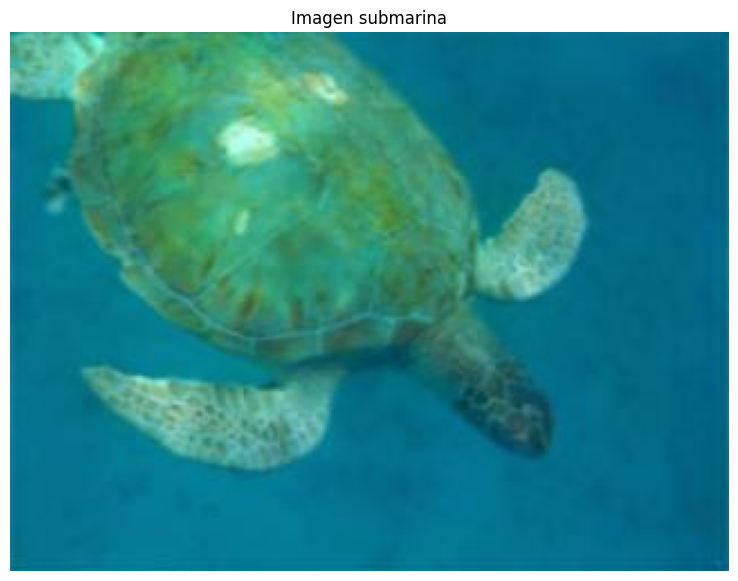

In [294]:
im = imagenes["Tortuga"]

plt.figure(figsize=(10, 7))
plt.imshow(im)
plt.title("Imagen submarina")
plt.axis("off")
plt.show()

In [295]:
im_ycbcr = color.rgb2ycbcr(im)

Y  = im_ycbcr[:, :, 0]
Cb = im_ycbcr[:, :, 1]
Cr = im_ycbcr[:, :, 2]

Y = ((Y - 16) / (235 - 16)) * 255

In [296]:
def normalizar(img, pmin=0, pmax=1):
    """
    Lleva una imagen al rango [0,1]
    usando percentiles para controlar outliers.
    """

    img = img.astype(float)

    minimo = np.nanpercentile(img, pmin)
    maximo = np.nanpercentile(img, pmax)

    img = (img - minimo) / (maximo - minimo)

    return np.clip(img, 0, 1)

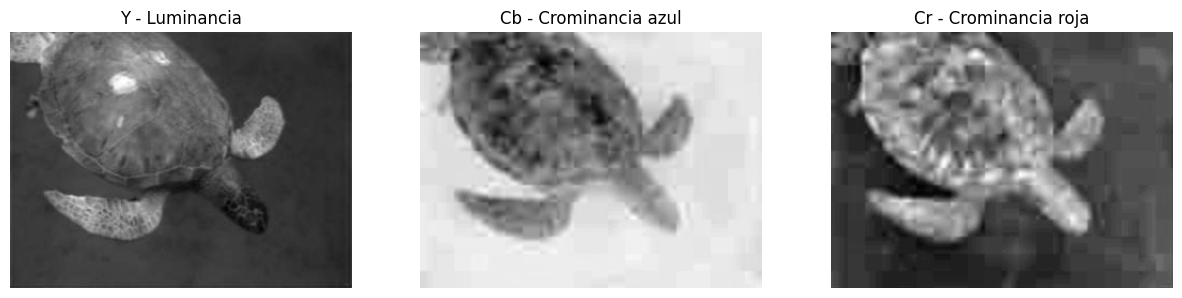

In [297]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(Y, cmap="gray")
ax[0].set_title("Y - Luminancia")

ax[1].imshow(Cb, cmap="gray")
ax[1].set_title("Cb - Crominancia azul")

ax[2].imshow(Cr, cmap="gray")
ax[2].set_title("Cr - Crominancia roja")

for a in ax:
    a.axis("off")

plt.show()

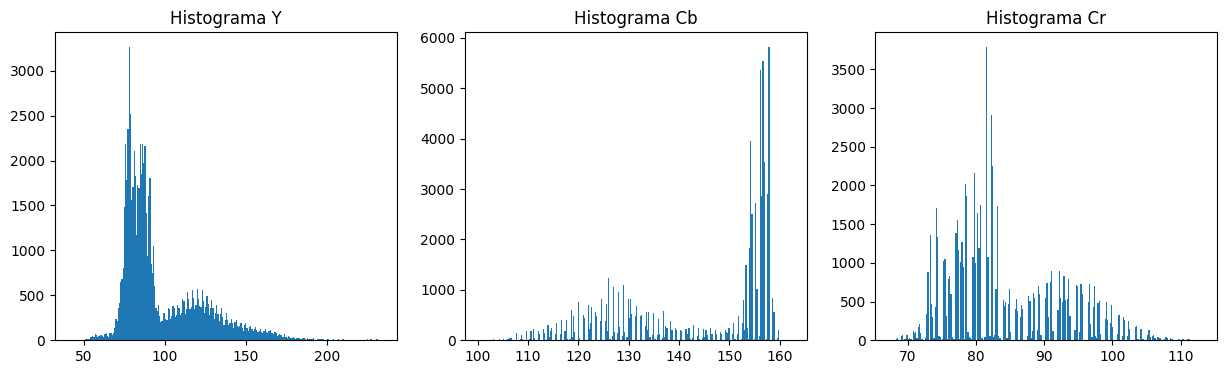

In [298]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(Y.ravel(), bins=256)
ax[0].set_title("Histograma Y")

ax[1].hist(Cb.ravel(), bins=256)
ax[1].set_title("Histograma Cb")

ax[2].hist(Cr.ravel(), bins=256)
ax[2].set_title("Histograma Cr")

plt.show()

In [299]:
print("Promedio Y :", np.mean(Y))
print("Promedio Cb:", np.mean(Cb))
print("Promedio Cr:", np.mean(Cr))

Promedio Y : 98.08466671875
Promedio Cb: 144.3163201782067
Promedio Cr: 84.13161977665442


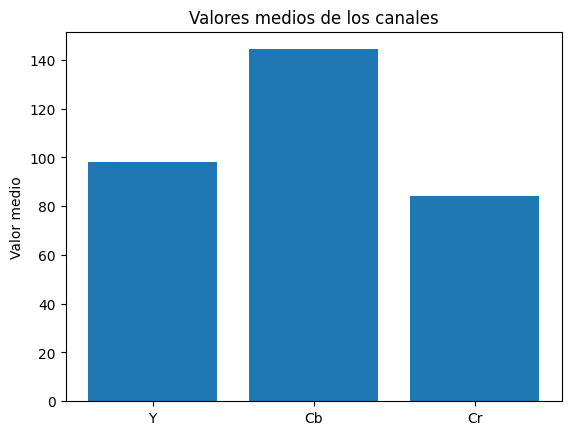

In [300]:
plt.bar(["Y", "Cb", "Cr"], [np.mean(Y), np.mean(Cb), np.mean(Cr)])
plt.ylabel("Valor medio")
plt.title("Valores medios de los canales")
plt.show()

In [301]:
Y_eq = exposure.equalize_hist(Y)

#Cb_eq = exposure.equalize_hist(Cb)
#Cr_eq = exposure.equalize_hist(Cr)

im_ycbcr_eq = im_ycbcr.copy()
im_ycbcr_eq[:, :, 0] = Y_eq * 255
#im_ycbcr_eq[:, :, 1] = Cb_eq * 255
#im_ycbcr_eq[:, :, 2] = Cr_eq * 255

In [302]:
im_eq = color.ycbcr2rgb(im_ycbcr_eq)

im_eq = np.clip(im_eq, 0, 1)

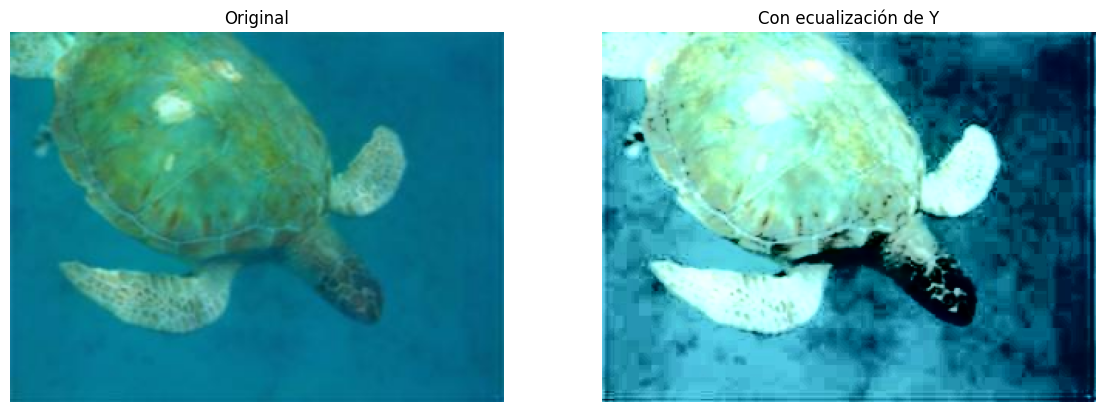

In [303]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].imshow(im)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(im_eq)
ax[1].set_title("Con ecualización de Y")
ax[1].axis("off")

plt.show()

In [304]:
Y_clahe = exposure.equalize_adapthist(Y / 255)

im_ycbcr_clahe = im_ycbcr.copy()
im_ycbcr_clahe[:, :, 0] = Y_clahe * 255

im_clahe = color.ycbcr2rgb(im_ycbcr_clahe)
im_clahe = np.clip(im_clahe, 0, 1)

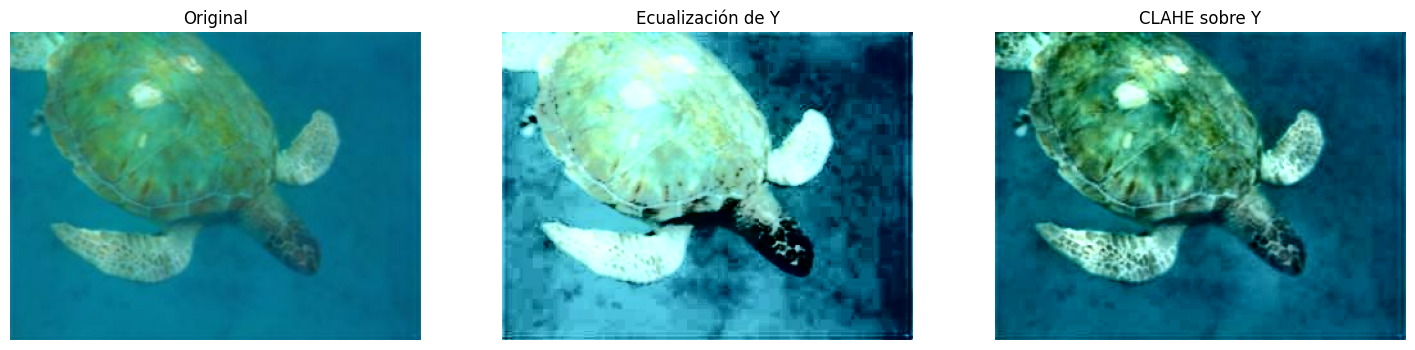

In [305]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(im)
ax[0].set_title("Original")

ax[1].imshow(im_eq)
ax[1].set_title("Ecualización de Y")

ax[2].imshow(im_clahe)
ax[2].set_title("CLAHE sobre Y")

for a in ax:
    a.axis("off")

plt.show()

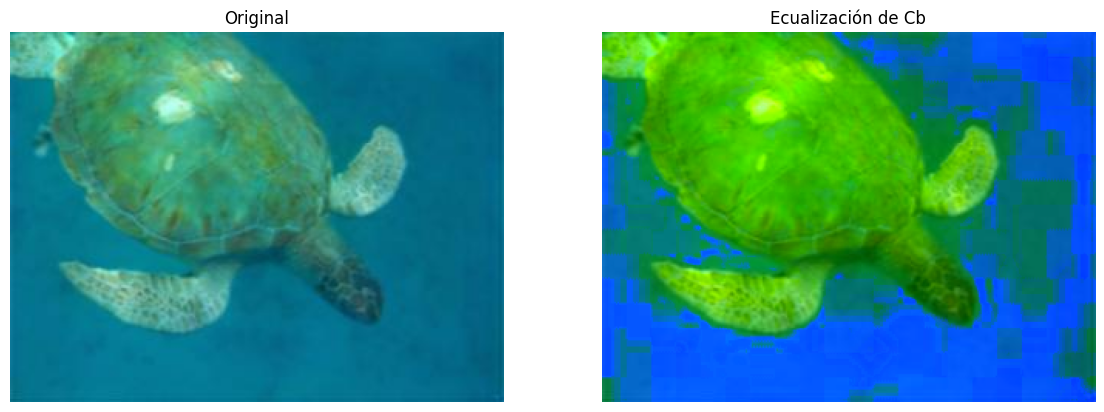

In [306]:
from skimage import exposure

Cb_eq = exposure.equalize_hist(Cb)

# Volver al rango [0, 255]
Cb_eq = Cb_eq * 255

im_ycbcr_eq = im_ycbcr.copy()

im_ycbcr_eq[:, :, 1] = Cb_eq

im_eq = color.ycbcr2rgb(im_ycbcr_eq)
im_eq = np.clip(im_eq, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].imshow(im)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(im_eq)
ax[1].set_title("Ecualización de Cb")
ax[1].axis("off")

plt.show()

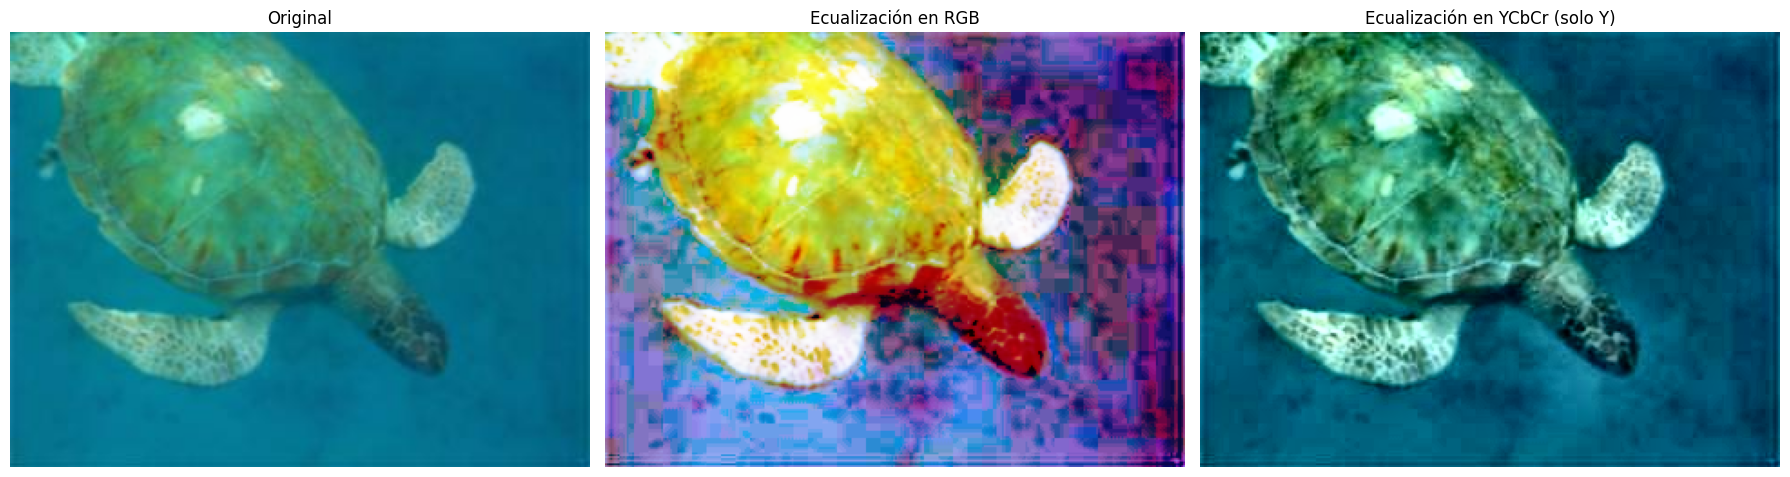

In [307]:
from skimage import color, exposure
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Ecualización de histograma en RGB
# ============================================================

im_rgb_eq = np.zeros_like(im, dtype=float)

for c in range(3):
    im_rgb_eq[:, :, c] = exposure.equalize_hist(im[:, :, c])


# ============================================================
# 2. Ecualización de histograma en YCbCr
# ============================================================

im_ycbcr = color.rgb2ycbcr(im)

Y  = im_ycbcr[:, :, 0]
Cb = im_ycbcr[:, :, 1]
Cr = im_ycbcr[:, :, 2]

# Ecualizamos solamente la luminancia
Y_eq = exposure.equalize_adapthist(Y / 255) * 255

im_ycbcr_eq = im_ycbcr.copy()
im_ycbcr_eq[:, :, 0] = Y_eq

# Volvemos a RGB
im_ycbcr_eq = color.ycbcr2rgb(im_ycbcr_eq)
im_ycbcr_eq = np.clip(im_ycbcr_eq, 0, 1)


# ============================================================
# 3. Comparación
# ============================================================

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(im)
ax[0].set_title("Original")

ax[1].imshow(im_rgb_eq)
ax[1].set_title("Ecualización en RGB")

ax[2].imshow(im_ycbcr_eq)
ax[2].set_title("Ecualización en YCbCr (solo Y)")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

In [336]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color

np.random.seed(42)

# Ruido gaussiano
sigma = 40

ruido = np.random.normal(0, sigma, im.shape)

im_rgb_ruido = im.astype(float) + ruido
im_rgb_ruido = np.clip(im_rgb_ruido, 0, 255).astype(np.uint8)

In [337]:
im_ycbcr = color.rgb2ycbcr(im)

Y  = im_ycbcr[:, :, 0]
Cb = im_ycbcr[:, :, 1]
Cr = im_ycbcr[:, :, 2]

In [338]:
ruido_Y = np.random.normal(0, sigma, Y.shape)

Y_ruido = Y + ruido_Y
Y_ruido = np.clip(Y_ruido, 0, 255)

im_ycbcr_ruido = im_ycbcr.copy()
im_ycbcr_ruido[:, :, 0] = Y_ruido

In [339]:
im_ycbcr_ruido = color.ycbcr2rgb(im_ycbcr_ruido)
im_ycbcr_ruido = np.clip(im_ycbcr_ruido, 0, 1)

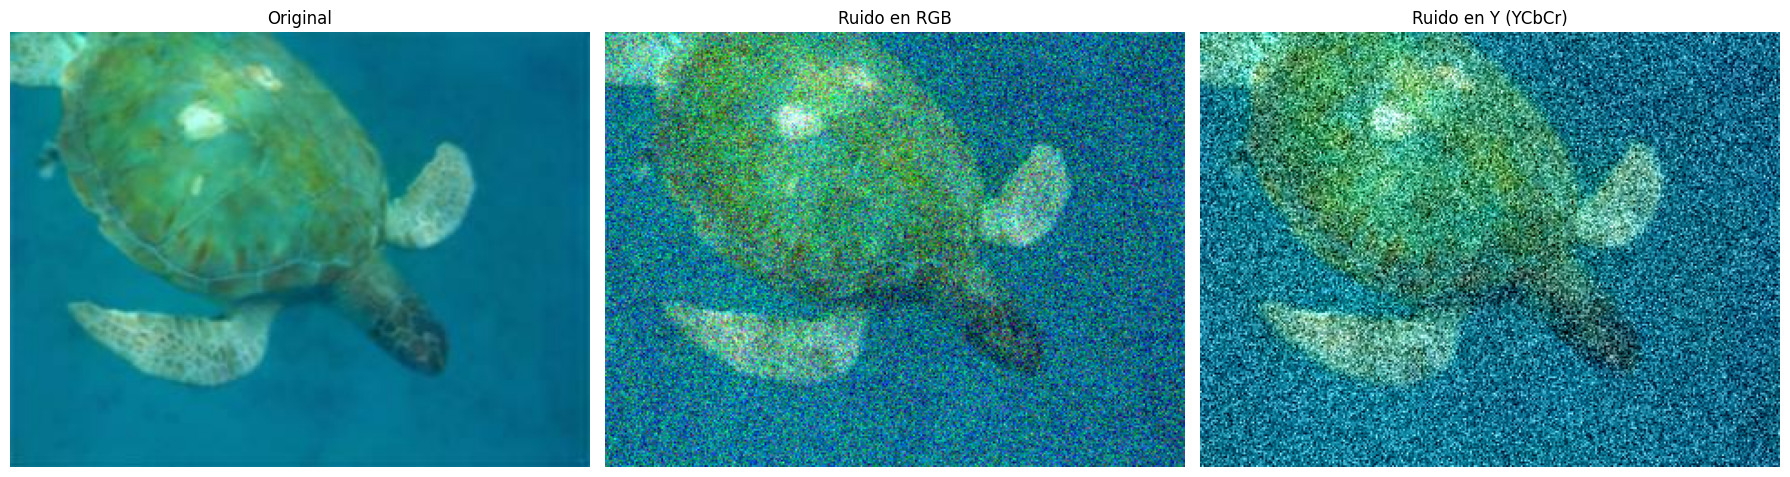

In [340]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(im)
ax[0].set_title("Original")

ax[1].imshow(im_rgb_ruido)
ax[1].set_title("Ruido en RGB")

ax[2].imshow(im_ycbcr_ruido)
ax[2].set_title("Ruido en Y (YCbCr)")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

In [341]:
ruido_Cb = np.random.normal(0, sigma, Cb.shape)
ruido_Cr = np.random.normal(0, sigma, Cr.shape)

im_ycbcr_color = im_ycbcr.copy()

im_ycbcr_color[:, :, 1] = np.clip(Cb + ruido_Cb, 0, 255)
im_ycbcr_color[:, :, 2] = np.clip(Cr + ruido_Cr, 0, 255)

im_ycbcr_color = color.ycbcr2rgb(im_ycbcr_color)
im_ycbcr_color = np.clip(im_ycbcr_color, 0, 1)

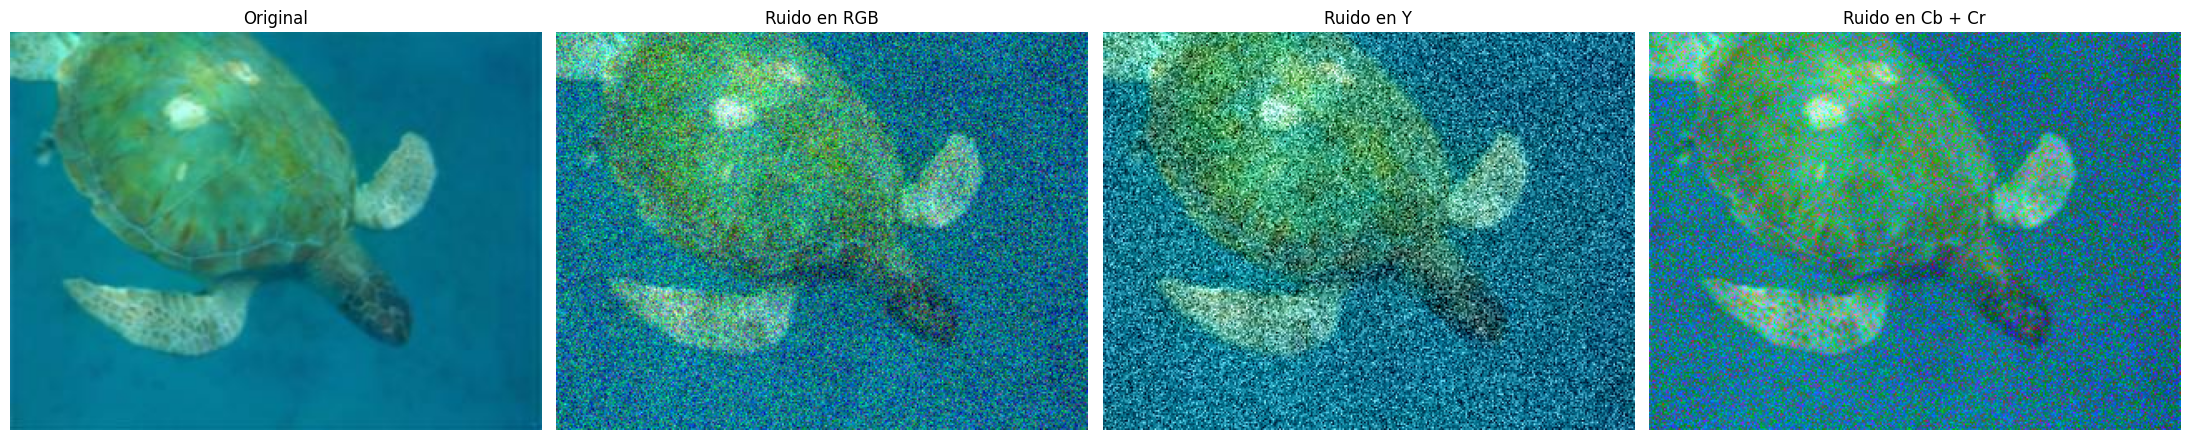

In [342]:
fig, ax = plt.subplots(1, 4, figsize=(22, 6))

ax[0].imshow(im)
ax[0].set_title("Original")

ax[1].imshow(im_rgb_ruido)
ax[1].set_title("Ruido en RGB")

ax[2].imshow(im_ycbcr_ruido)
ax[2].set_title("Ruido en Y")

ax[3].imshow(im_ycbcr_color)
ax[3].set_title("Ruido en Cb + Cr")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()